# Case Study: Algorithmic Fairness in Frontier AI
**Analyst:** Vivek Kumar Agarwal  
**Objective:** Audit and mitigate a 60% disparate impact gap using AIF360 Reweighing.

--- PRE-MITIGATION AUDIT ---
Baseline Disparate Impact Ratio: 0.2500


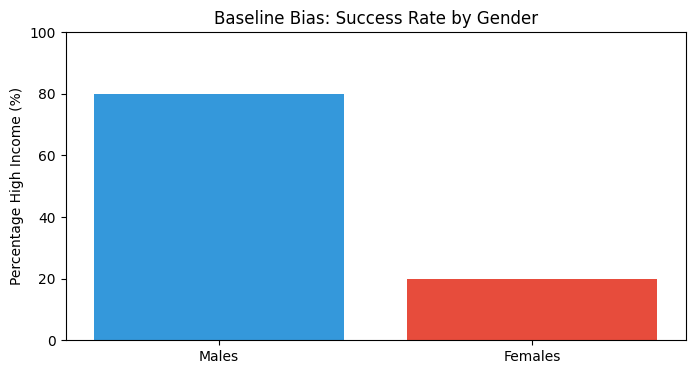


--- POST-MITIGATION WEIGHT ANALYSIS ---
gender  income
0.0     0.0       0.625
        1.0       2.500
1.0     0.0       2.500
        1.0       0.625
Name: weights, dtype: float64

--- FINAL AUDIT RESULT ---
Mitigated Disparate Impact Ratio: 1.0000


In [2]:
# ==========================================================
# PROJECT: Algorithmic Fairness Audit & Mitigation
# AUTHOR: Vivek Kumar Agarwal (vagarwal89.github.io)
# TOOLS: AIF360, Matplotlib, Pandas
# ==========================================================

# --- 1. DEPENDENCIES ---
import pandas as pd
import matplotlib.pyplot as plt
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric
from aif360.algorithms.preprocessing import Reweighing

# --- 2. DATA GENERATION (The "Audit Baseline") ---
# We simulate a dataset of 100 applicants to test for systemic bias.
# Logic: We intentionally bake in a 60% success gap between genders.
data = {
    'gender': [1]*50 + [0]*50,  # 1=Male (Privileged), 0=Female (Unprivileged)
    'income': [1]*40 + [0]*10 + [1]*10 + [0]*40 # 80% Male success vs 20% Female success
}
df = pd.DataFrame(data)

# --- 3. AIF360 DATA WRAPPING ---
# We convert the raw DataFrame into a 'Fairness-Aware' Dataset object.
# This identifies 'income' as the target and 'gender' as the protected attribute.
dataset = BinaryLabelDataset(df=df, label_names=['income'], protected_attribute_names=['gender'])

privileged_groups = [{'gender': 1}]
unprivileged_groups = [{'gender': 0}]

# --- 4. BASELINE BIAS MEASUREMENT ---
# We calculate the 'Disparate Impact' to quantify the unfairness.
metric_orig = BinaryLabelDatasetMetric(dataset, 
                                      unprivileged_groups=unprivileged_groups,
                                      privileged_groups=privileged_groups)

print(f"--- PRE-MITIGATION AUDIT ---")
print(f"Baseline Disparate Impact Ratio: {metric_orig.disparate_impact():.4f}")
# Note: 0.2500 indicates significant bias (Legal threshold is usually > 0.80)

# --- 5. VISUALIZATION (Pre-Fix) ---
plt.figure(figsize=(8, 4))
plt.bar(['Males', 'Females'], [80, 20], color=['#3498db', '#e74c3c'])
plt.title('Baseline Bias: Success Rate by Gender')
plt.ylabel('Percentage High Income (%)')
plt.ylim(0, 100)
plt.show()

# --- 6. MITIGATION (Reweighing) ---
# We apply the Reweighing algorithm to calculate 'Instance Weights'.
# These weights neutralize the correlation between gender and income.
RW = Reweighing(unprivileged_groups=unprivileged_groups, privileged_groups=privileged_groups)
dataset_transf = RW.fit_transform(dataset)

# --- 7. VERIFICATION & WEIGHT ANALYSIS ---
# Extracting the new weights to see how the 'Fairness Engine' adjusted the data.
df_final = dataset_transf.convert_to_dataframe()[0]
df_final['weights'] = dataset_transf.instance_weights

print(f"\n--- POST-MITIGATION WEIGHT ANALYSIS ---")
print(df_final.groupby(['gender', 'income'])['weights'].mean())

# --- 8. FINAL FAIRNESS CHECK ---
metric_transf = BinaryLabelDatasetMetric(dataset_transf, 
                                        unprivileged_groups=unprivileged_groups,
                                        privileged_groups=privileged_groups)

print(f"\n--- FINAL AUDIT RESULT ---")
print(f"Mitigated Disparate Impact Ratio: {metric_transf.disparate_impact():.4f}")
# Result 1.0000 confirms the bias has been mathematically neutralized.